In [101]:
import pandas as pd

In [102]:
covid_df = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv")
covid_df.head()

covid_itly = covid_df[covid_df['Country/Region']=='Italy'].drop(['Province/State','Lat','Long'], axis = 1)
covid_itly.head()



,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
154,Italy,0,0,0,0,0,0,0,0,0,...,25576852,25576852,25576852,25603510,25603510,25603510,25603510,25603510,25603510,25603510


In [103]:
#question 1
covid_itly_df_long = covid_itly.melt(
    id_vars=['Country/Region'],     
    var_name='date',        
    value_name='COVID_cases' 
)

covid_itly_df_long['date'] = pd.to_datetime(covid_itly_df_long['date'])
first_case_date = covid_itly_df_long.loc[covid_itly_df_long['COVID_cases'] > 0, 'date'].min()
print(first_case_date)

2020-01-31 00:00:00


/tmp/ipykernel_3642/846177064.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  covid_itly_df_long['date'] = pd.to_datetime(covid_itly_df_long['date'])


In [104]:
#question 1
covid_itly_wrkng_df = covid_itly_df_long[covid_itly_df_long['date']>=first_case_date].drop(['Country/Region'],axis = 1)
covid_itly_wrkng_df.head()

,date,COVID_cases
9,2020-01-31,2
10,2020-02-01,2
11,2020-02-02,2
12,2020-02-03,2
13,2020-02-04,2


In [105]:

#question 1
# create lag features
for lag in range(1, 6):
    covid_itly_wrkng_df[f'y_lag{lag}'] = covid_itly_wrkng_df['COVID_cases'].shift(lag)

# drop rows with NaNs (first 5 rows)
df_itly_model = covid_itly_wrkng_df.dropna()

In [106]:
#question 1
import statsmodels.api as sm

X = df_itly_model[[f'y_lag{lag}' for lag in range(1, 6)]]
X = sm.add_constant(X)

y = df_itly_model['COVID_cases']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            COVID_cases   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.433e+07
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:29:41   Log-Likelihood:                -12950.
No. Observations:                1129   AIC:                         2.591e+04
Df Residuals:                    1123   BIC:                         2.594e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1931.7367   1011.838      1.909      0.0

#question 1
Interpreting the Coefficients
Only lag 1 and lag 5 have a p-value less than .05 so those are the only significant predictors accounting for the others. Somehow the day before and 5 days before were predictive.

y_lag1 coefficient of 1.29 interpretation: for a 1 case increase for COVID cases the day before, translated to an avg 1.29 increase in COVID cases for that day, holding all else constant

y_lag2 coefficient of -0.85 interpretation: for a 1 case increase for COVID cases 2 days before, translated to an avg 0.85 decrease in COVID cases for that day, holding all else constant

y_lag3 and y_lag4 coefficients are close to 0 so have a negligible impact on COVID cases given the COVID cases 3 and 4 days prior, respectively, holding all else constant

y_lag5 coefficient of -0.194 interpretation: for a 1 case increase for COVID cases 5 days before, translated to an avg 0.194 decrease in COVID cases for that day, holding all else constant


In [107]:
#question 2a

import statsmodels.api as sm
import numpy as np

X = df_itly_model[[f'y_lag{lag}' for lag in range(1, 6)]]
X = sm.add_constant(X)

y = df_itly_model['COVID_cases']

#use model from previous cell

# predicted values
df_itly_model['y_pred_allA'] = model.predict(X)

# MSE
MSE = ((df_itly_model['COVID_cases'] - df_itly_model['y_pred_allA'])**2).mean()
RMSE = MSE**.5
print('MSE:', MSE)
print('RMSE:', RMSE)

df_itly_model['error_allA'] = (df_itly_model['COVID_cases'] - df_itly_model['y_pred_allA'])**2

MSE: 537408215.1716063
RMSE: 23182.066671709974


In [108]:
#question 2b

split_idx = len(df_itly_model) // 2
train = df_itly_model.iloc[:split_idx].copy()
test = df_itly_model.iloc[split_idx:].copy()

X_train = train[[f'y_lag{lag}' for lag in range(1, 6)]].dropna()
X_train = sm.add_constant(X_train)

train_model = train.dropna()

y_train = train_model['COVID_cases']

model_b = sm.OLS(y_train, X_train).fit()

# combine all lag columns
X_test = test[[f'y_lag{lag}' for lag in range(1, 6)]]

# drop any rows with NaN (first few will be NaN due to shift)
X_test = X_test.dropna()

# align test DataFrame to X_test rows
test_aligned = test.loc[X_test.index]

# add constant
X_test = sm.add_constant(X_test)

test_aligned['y_pred'] = model_b.predict(X_test)

MSE = ((test['COVID_cases'] - test_aligned['y_pred'])**2).mean()
RMSE = MSE**.5
print('MSE:', MSE)
print('RMSE:', RMSE)

test['error'] = (test['COVID_cases'] - test_aligned['y_pred'])**2

MSE: 1849225311.6021469
RMSE: 43002.61982254275


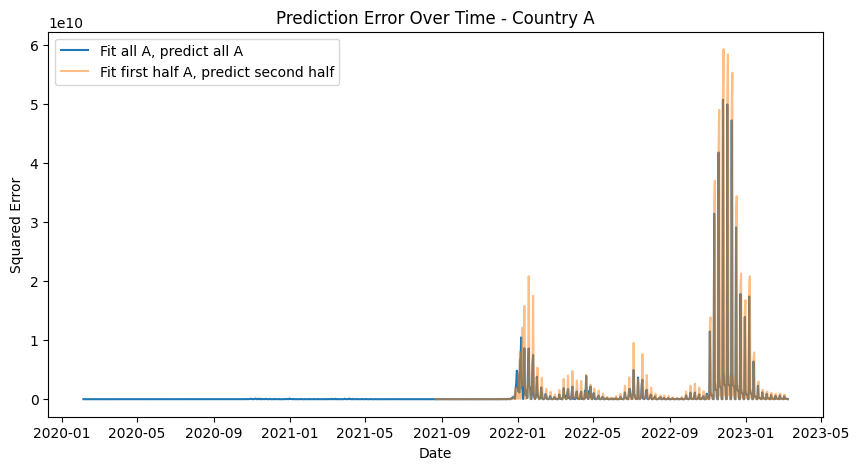

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_itly_model['date'], df_itly_model['error_allA'], label='Fit all A, predict all A')
plt.plot(test['date'], test['error'], label='Fit first half A, predict second half', alpha = .5)
plt.xlabel('Date')
plt.ylabel('Squared Error')
plt.title('Prediction Error Over Time - Country A')
plt.legend()
plt.show()

In [110]:
#question 3

covid_fr = covid_df[(covid_df['Country/Region']=='France') & (covid_df['Province/State'].isna())].drop(['Province/State','Lat','Long'], axis = 1)

covid_fr_df_long = covid_fr.melt(
    id_vars=['Country/Region'],     
    var_name='date',        
    value_name='COVID_cases' 
)

covid_fr_df_long['date'] = pd.to_datetime(covid_fr_df_long['date'])
first_case_date_fr = covid_fr_df_long.loc[covid_fr_df_long['COVID_cases'] > 0, 'date'].min()
print(first_case_date_fr)

2020-01-24 00:00:00


/tmp/ipykernel_3642/1206134712.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  covid_fr_df_long['date'] = pd.to_datetime(covid_fr_df_long['date'])


In [111]:
#question 3
covid_fr_wrkng_df = covid_fr_df_long[covid_fr_df_long['date']>first_case_date_fr].drop(['Country/Region'],axis = 1)
covid_fr_wrkng_df.head()

,date,COVID_cases
3,2020-01-25,3
4,2020-01-26,3
5,2020-01-27,3
6,2020-01-28,4
7,2020-01-29,5


In [112]:
#question 3
# create lag features
for lag in range(1, 6):
    covid_fr_wrkng_df[f'y_lag{lag}'] = covid_fr_wrkng_df['COVID_cases'].shift(lag)

# drop rows with NaNs (first 5 rows)
df_fr_model = covid_fr_wrkng_df.dropna()

In [113]:
#question 3
X_fr = df_fr_model[[f'y_lag{lag}' for lag in range(1, 6)]]
X_fr = sm.add_constant(X_fr)

y_fr = df_fr_model['COVID_cases']

# predicted values from model in question 2a and 1
df_fr_model['y_pred_fr'] = model.predict(X_fr)

# MSE
MSE_fr = ((df_fr_model['COVID_cases'] - df_fr_model['y_pred_fr'])**2).mean()
RMSE_fr = MSE_fr**.5
print("MSE France using Italy's Model:", MSE_fr)
print("RMSE France using Italy's model:", RMSE_fr)

df_fr_model['error_fr'] = (df_fr_model['COVID_cases'] - df_fr_model['y_pred_fr'])**2



MSE France using Italy's Model: 1539510432.2784252
RMSE France using Italy's model: 39236.59557451978


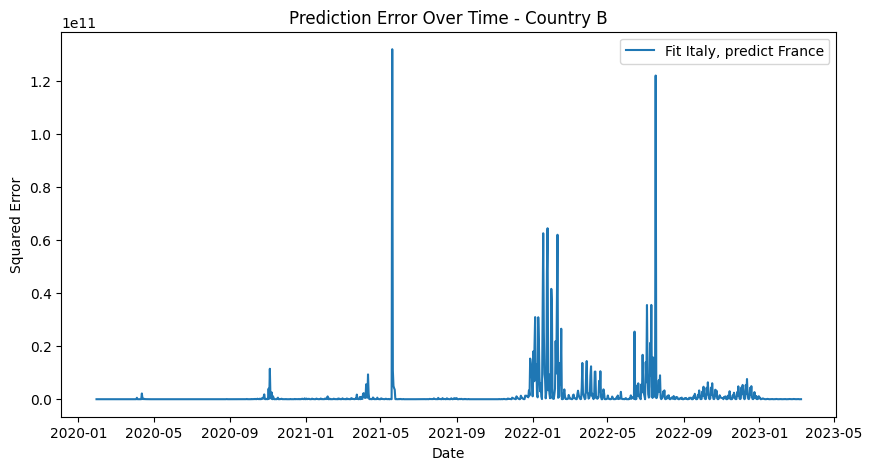

In [114]:
#question 3
plt.figure(figsize=(10,5))
plt.plot(df_fr_model['date'], df_fr_model['error_fr'], label='Fit Italy, predict France')
plt.xlabel('Date')
plt.ylabel('Squared Error')
plt.title('Prediction Error Over Time - Country B')
plt.legend()
plt.show()

In [115]:
#problem 4
covid_itly_wrkng_df = covid_itly_wrkng_df.reset_index(drop=True)
covid_itly_wrkng_df['inc_flag'] = (covid_itly_wrkng_df['COVID_cases']>covid_itly_wrkng_df['COVID_cases'].shift(1)).astype(int)
covid_itly_wrkng_df.loc[0, 'inc_flag'] = 1  # first row set to 1 since first non-zero date

covid_itly_wrkng_df.head(10)

,date,COVID_cases,y_lag1,y_lag2,y_lag3,y_lag4,y_lag5,inc_flag
0,2020-01-31,2,NaN,NaN,NaN,NaN,NaN,1
1,2020-02-01,2,2.0,NaN,NaN,NaN,NaN,0
2,2020-02-02,2,2.0,2.0,NaN,NaN,NaN,0
3,2020-02-03,2,2.0,2.0,2.0,NaN,NaN,0
4,2020-02-04,2,2.0,2.0,2.0,2.0,NaN,0
5,2020-02-05,2,2.0,2.0,2.0,2.0,2.0,0
6,2020-02-06,2,2.0,2.0,2.0,2.0,2.0,0
7,2020-02-07,3,2.0,2.0,2.0,2.0,2.0,1
8,2020-02-08,3,3.0,2.0,2.0,2.0,2.0,0
9,2020-02-09,3,3.0,3.0,2.0,2.0,2.0,0


In [116]:
#question 4
# create lag features
for lag in range(1, 6):
    covid_itly_wrkng_df[f'y_inc_flg_lag{lag}'] = covid_itly_wrkng_df['inc_flag'].shift(lag)

# drop rows with NaNs (first 5 rows)
df_itly_model_inc_flg = covid_itly_wrkng_df.dropna()

In [117]:
#question 4
X = df_itly_model_inc_flg[[f'y_inc_flg_lag{lag}' for lag in range(1, 6)]]
X = sm.add_constant(X)

y = df_itly_model_inc_flg['inc_flag']

model_inc_flg = sm.Logit(y, X).fit()
print(model_inc_flg.summary())

Optimization terminated successfully.
         Current function value: 0.095026
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               inc_flag   No. Observations:                 1129
Model:                          Logit   Df Residuals:                     1123
Method:                           MLE   Df Model:                            5
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.7326
Time:                        10:29:42   Log-Likelihood:                -107.28
converged:                       True   LL-Null:                       -401.17
Covariance Type:            nonrobust   LLR p-value:                8.879e-125
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.8104      0.287     -9.797      0.000      -3.373      -2.248
y_inc_flg_lag1   

#question 4
Interpreting the Coefficients
All lags have p-values less than .05 so they are all significant predictors and all positive, meaning if there was an increase in days 1 to 5 prior, this is predictive of an increase in COVID cases the day of.

y_lag1 coefficient of 2.13 interpretation: an increase in COVID cases as of the day before, translated to an avg increase in the log odds of having an increase in COVID cases for that day of 2.13, holding all else constant

y_lag2 coefficient of 1.73 interpretation: an increase in COVID cases as of 2 days before, translated to an avg increase in the log odds of having an increase in COVID cases for that day of 1.73, holding all else constant

y_lag3 coefficient of 1.43 interpretation: an increase in COVID cases as of 3 days before, translated to an avg increase in the log odds of having an increase in COVID cases for that day of 1.43, holding all else constant

y_lag4 coefficient of 1.27 interpretation: an increase in COVID cases as of 4 days before, translated to an avg increase in the log odds of having an increase in COVID cases for that day of 1.27, holding all else constant

y_lag5 coefficient of 1.14 interpretation: an increase in COVID cases as of 5 days before, translated to an avg increase in the log odds of having an increase in COVID cases for that day of 1.14, holding all else constant